In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

In [2]:
df = pd.read_csv("dataset_amoxy.csv")
df_small = df.sample(30000, random_state=42)

In [3]:
df_small

,Unnamed: 0,Species,Organism Group,Country,Year,Source,Value,Value_I
121137,121137,Klebsiella pneumoniae,Enterobacteriaceae,United States,2004,ENT,4.00,Susceptible
237461,237461,Serratia marcescens,Enterobacteriaceae,Mexico,2009,BF,32.00,Resistant
7123,7123,Providencia rettgeri,Enterobacteriaceae,Sweden,2013,GI,16.00,Resistant
189416,189416,Klebsiella aerogenes,Enterobacteriaceae,India,2007,RSP,16.00,Intermediate
213619,213619,Klebsiella pneumoniae,Enterobacteriaceae,Italy,2008,GU,32.00,Resistant
...,...,...,...,...,...,...,...,...
84497,84497,Escherichia coli,Enterobacteriaceae,Mexico,2016,INT,4.00,Susceptible
295408,295408,Klebsiella pneumoniae,Enterobacteriaceae,Turkey,2012,GU,16.00,Resistant
183408,183408,Serratia marcescens,Enterobacteriaceae,United States,2007,CVS,32.00,Resistant
155349,155349,Streptococcus pneumoniae,Streptococcus pneumoniae,Japan,2017,RSP,0.06,Susceptible


In [4]:
df_small['Year_c'] = df_small['Year'] - df_small['Year'].mean()
species_idx, species = pd.factorize(df_small["Species"])
country_idx, country = pd.factorize(df_small["Country"])
source_idx, source = pd.factorize(df_small["Source"])

df_small["species_idx"] = species_idx
df_small["country_idx"] = country_idx
df_small["source_idx"] = source_idx

In [5]:
trace = az.from_netcdf("trace_amoxy.nc")

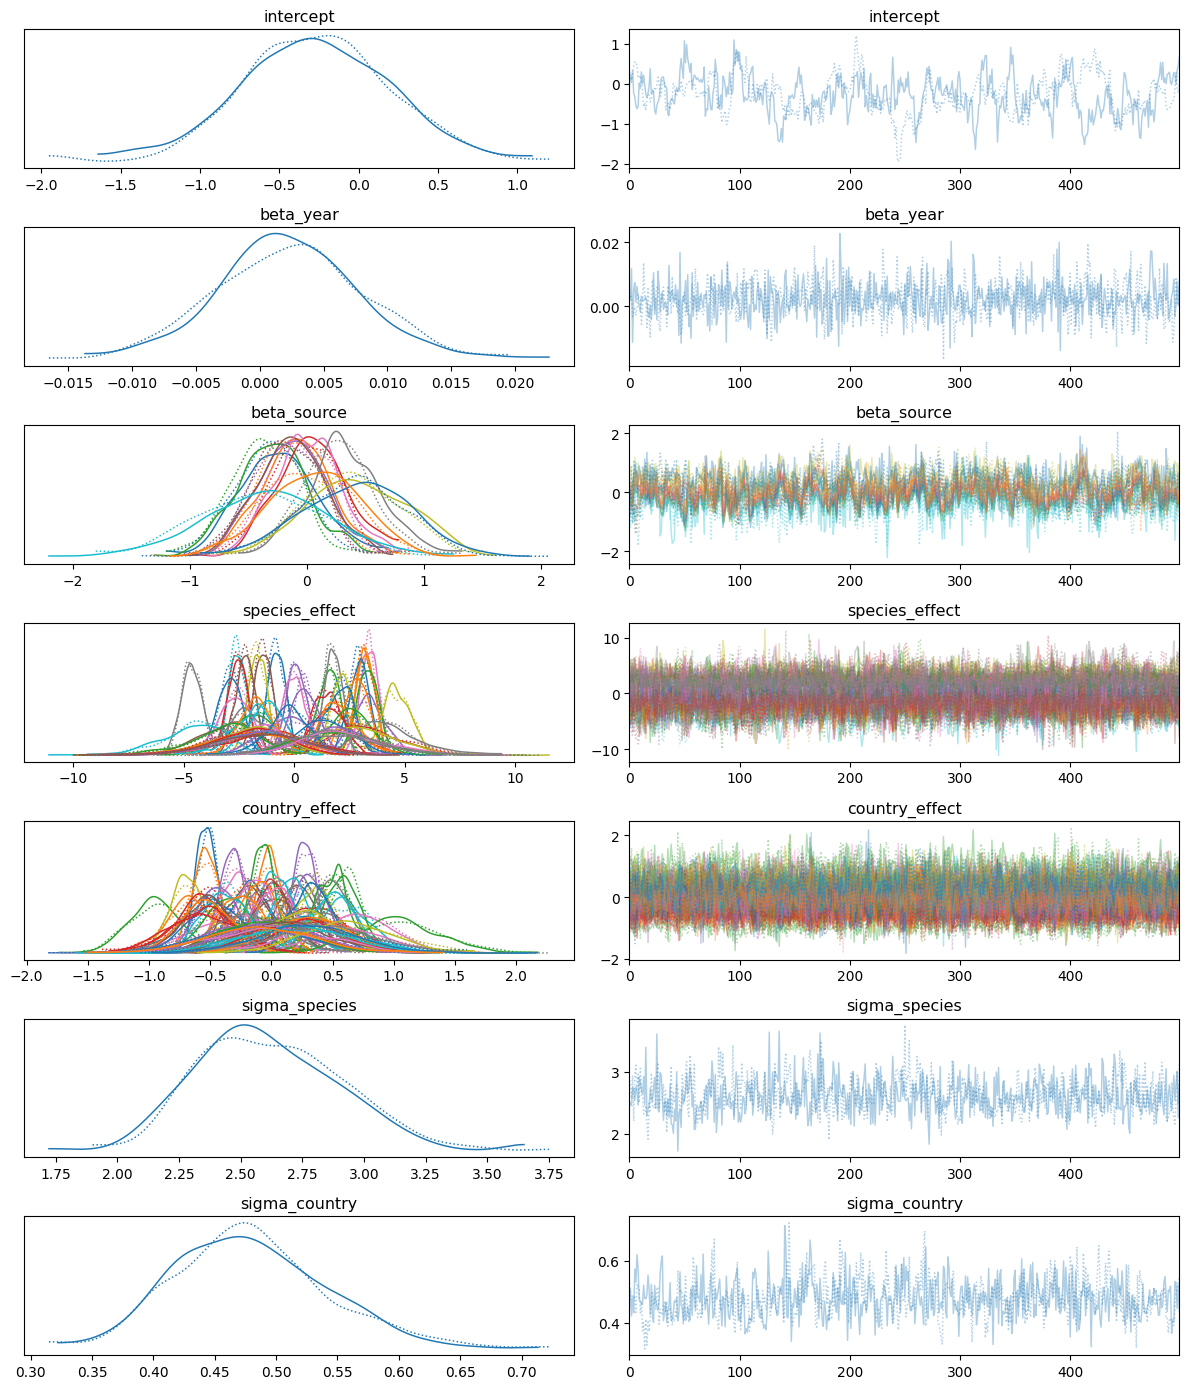

In [6]:
az.plot_trace(trace)
plt.savefig('/home/dark/Pictures/result.jpeg', dpi = 600)
plt.tight_layout()

In [7]:
beta_year_samples = trace.posterior["beta_year"].values
beta_mean = beta_year_samples.mean()
beta_ci = np.percentile(beta_year_samples, [2.5, 97.5])

print("Mean:", beta_mean)
print("95% CI:", beta_ci)

Mean: 0.002271498325892621
95% CI: [-0.00887439  0.01350242]


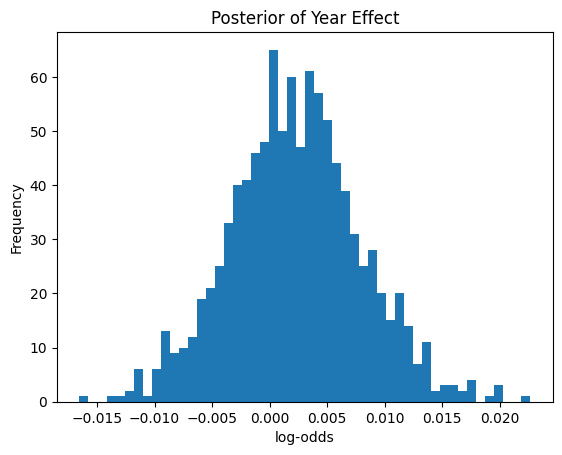

In [8]:
plt.hist(beta_year_samples.flatten(), bins=50)
plt.title("Posterior of Year Effect")
plt.xlabel("log-odds")
plt.ylabel("Frequency")
plt.show()

Country wise

In [9]:
country_samples = trace.posterior["country_effect"].values

In [6]:
country_mean = country_samples.mean(axis=(0,1))

In [7]:
intercept_mean = trace.posterior["intercept"].values.mean()

country_prob = 1 / (1 + np.exp(-(intercept_mean + country_mean)))

In [ ]:
country_df = pd.DataFrame({
    "Country": country,
    "Resistance_Prob": country_prob
})

In [51]:
country_ci = np.percentile(country_samples, [2.5, 97.5], axis=(0,1))

lower = 1 / (1 + np.exp(-(intercept_mean + country_ci[0])))
upper = 1 / (1 + np.exp(-(intercept_mean + country_ci[1])))

In [52]:
country_df["lower"] = lower
country_df["upper"] = upper

In [53]:
country_data_ser = df_small[df_small.Value_I == 'Resistant']['Country'].value_counts()


In [54]:
valid_countries = country_data_ser[country_data_ser > 100].index

filtered_df = country_df[country_df["Country"].isin(valid_countries)]

In [55]:
country_df_sorted = filtered_df.sort_values(by="Resistance_Prob", ascending=False)

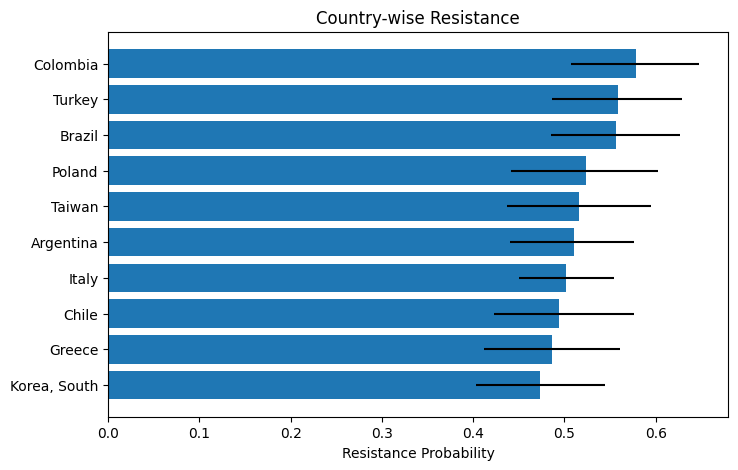

In [59]:
top_countries = country_df_sorted.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_countries["Country"], top_countries["Resistance_Prob"],
         xerr=[top_countries["Resistance_Prob"] - top_countries["lower"],
               top_countries["upper"] - top_countries["Resistance_Prob"]])

plt.gca().invert_yaxis()
plt.xlabel("Resistance Probability")
plt.title("Country-wise Resistance")
plt.show()

Species Wise

In [88]:
species_samples = trace.posterior["species_effect"].values

In [89]:
species_mean = species_samples.mean(axis=(0,1))

In [90]:
intercept_mean = trace.posterior["intercept"].values.mean()

species_prob = 1 / (1 + np.exp(-(intercept_mean + species_mean)))

In [91]:
species_ci = np.percentile(species_samples, [2.5, 97.5], axis=(0,1))

lower = 1 / (1 + np.exp(-(intercept_mean + species_ci[0])))
upper = 1 / (1 + np.exp(-(intercept_mean + species_ci[1])))

In [92]:
species_df = pd.DataFrame({
    "Species": species,
    "Resistance_Prob": species_prob,
    "lower": lower,
    "upper": upper
})

In [101]:
counts = df_small[df.Value_I == 'Resistant']['Species'].value_counts()

/tmp/ipykernel_8172/1680593579.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  counts = df_small[df.Value_I == 'Resistant']['Species'].value_counts()


In [113]:
counts.mean()

np.float64(230.3181818181818)

In [117]:
l = []
for s in species_df.Species:
    try:
        l.append(counts[s])
    except:
        l.append(0)

In [105]:
species_df['count'] = l

In [114]:
species_df = species_df[species_df["count"] > 230]

In [115]:
species_df_sorted = species_df.sort_values(by="Resistance_Prob", ascending=False)

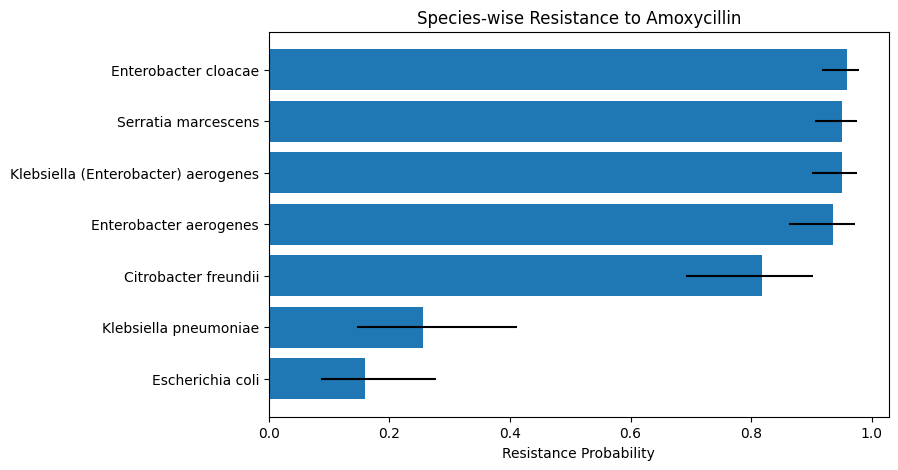

In [116]:
top_species = species_df_sorted.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top_species["Species"],
    top_species["Resistance_Prob"],
    xerr=[
        top_species["Resistance_Prob"] - top_species["lower"],
        top_species["upper"] - top_species["Resistance_Prob"]
    ]
)

plt.gca().invert_yaxis()
plt.xlabel("Resistance Probability")
plt.title("Species-wise Resistance to Amoxycillin")
plt.show()

Source wise

In [118]:
source_samples = trace.posterior["beta_source"].values

In [119]:
source_mean = source_samples.mean(axis=(0,1))

In [120]:
intercept_mean = trace.posterior["intercept"].values.mean()

source_prob = 1 / (1 + np.exp(-(intercept_mean + source_mean)))

In [121]:
source_ci = np.percentile(source_samples, [2.5, 97.5], axis=(0,1))

lower = 1 / (1 + np.exp(-(intercept_mean + source_ci[0])))
upper = 1 / (1 + np.exp(-(intercept_mean + source_ci[1])))

In [122]:
source_df = pd.DataFrame({
    "Source": source,
    "Resistance_Prob": source_prob,
    "lower": lower,
    "upper": upper
})

In [124]:
counts = df_small[df.Value_I == 'Resistant']['Source'].value_counts()

/tmp/ipykernel_8172/3007300479.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  counts = df_small[df.Value_I == 'Resistant']['Source'].value_counts()


In [125]:
l = []
for s in source_df.Source:
    try:
        l.append(counts[s])
    except:
        l.append(0)

In [126]:
source_df["count"] = l

In [127]:
counts.mean()

np.float64(840.5)

In [134]:
source_df = source_df[source_df["count"] > 1000]

In [135]:
source_df_sorted = source_df.sort_values(by="Resistance_Prob", ascending=False)

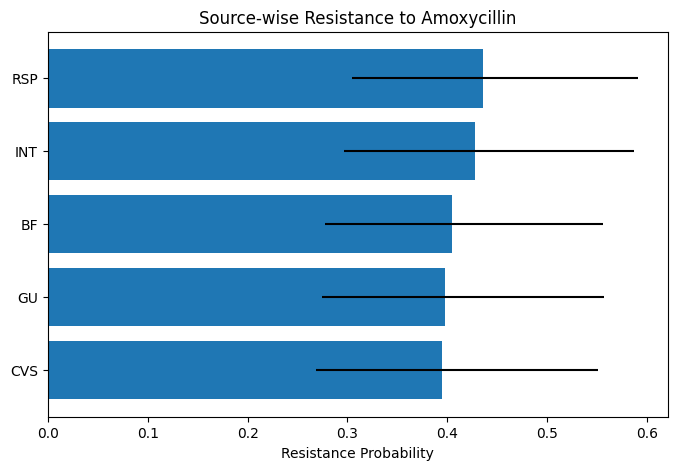

In [136]:
plt.figure(figsize=(8,5))

plt.barh(
    source_df_sorted["Source"],
    source_df_sorted["Resistance_Prob"],
    xerr=[
        source_df_sorted["Resistance_Prob"] - source_df_sorted["lower"],
        source_df_sorted["upper"] - source_df_sorted["Resistance_Prob"]
    ]
)

plt.gca().invert_yaxis()
plt.xlabel("Resistance Probability")
plt.title("Source-wise Resistance to Amoxycillin")
plt.show()